# MRNet ACL Tear Detection Pipeline
**Task:** Binary classification — ACL Tear vs No Tear  
**Dataset:** MRNet (Stanford) — Sagittal plane only  
**Framework:** PyTorch + ResNet18 (Transfer Learning)  
**Environment:** Google Colab T4 GPU  

---
Run cells **one at a time, in order**.

In [ ]:
# ─────────────────────────────────────────────────────────────
# CELL 1 — Mount Drive & Unzip Data
# ─────────────────────────────────────────────────────────────
# Run this cell first EVERY TIME you open a new Colab session.
# Colab session storage resets when the session ends.
# Your zip stays safe in Drive — we just unzip it each session.

from google.colab import drive
import zipfile, os

# Mount Google Drive
drive.mount('/content/drive')

# ── Paths ────────────────────────────────────────────────────
# Change ZIP_PATH if your zip is in a subfolder inside Drive
ZIP_PATH   = '/content/drive/MyDrive/MRNet_ACL.zip'
EXTRACT_TO = '/content/MRNet_ACL'

# Only unzip if not already extracted (saves time on re-runs)
if not os.path.exists(EXTRACT_TO):
    print('Unzipping... this takes 2-3 minutes')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_TO)
    print('✓ Unzip complete')
else:
    print('✓ Data already extracted — skipping unzip')

# ── Verify folder structure ───────────────────────────────────
print('\nFolder structure:')
for root, dirs, files in os.walk(EXTRACT_TO):
    level  = root.replace(EXTRACT_TO, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 4:
        for f in sorted(files)[:2]:
            print(f'{indent}  {f}')

In [2]:
# ─────────────────────────────────────────────────────────────
# CELL 2 — Imports & Configuration
# ─────────────────────────────────────────────────────────────

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms.functional as TF

# ── Reproducibility ───────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# ── Device ────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

# ── Paths ─────────────────────────────────────────────────────
BASE_DIR       = '/content/MRNet_ACL/MRNet_ACL'
TRAIN_DIR      = os.path.join(BASE_DIR, 'MRNet-v1.0', 'train', 'sagittal')
VALID_DIR      = os.path.join(BASE_DIR, 'MRNet-v1.0', 'valid', 'sagittal')
TRAIN_CSV      = os.path.join(BASE_DIR, 'train-acl.csv')
VALID_CSV      = os.path.join(BASE_DIR, 'valid-acl.csv')
CHECKPOINT_DIR = '/content/checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# ── Verify all paths exist ────────────────────────────────────
print('\nPath verification:')
all_ok = True
for path, name in [
    (TRAIN_DIR, 'Train sagittal'),
    (VALID_DIR, 'Valid sagittal'),
    (TRAIN_CSV, 'Train CSV'),
    (VALID_CSV, 'Valid CSV'),
]:
    ok = os.path.exists(path)
    print(f'  {"✓" if ok else "✗ NOT FOUND"} {name}: {path}')
    if not ok:
        all_ok = False

if not all_ok:
    raise FileNotFoundError('Some paths are missing. Check BASE_DIR.')

# ── Hyperparameters ───────────────────────────────────────────
CONFIG = {
    'batch_size'    : 8,      # T4 GPU handles this comfortably
    'num_epochs'    : 30,
    'learning_rate' : 1e-4,
    'weight_decay'  : 1e-5,
    'patience'      : 7,
    'num_workers'   : 2,      # Colab runs Linux — multiprocessing works fine
    'img_size'      : 224,
}

print(f'\n✓ Config: {CONFIG}')

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB

Path verification:
  ✓ Train sagittal: /content/MRNet_ACL/MRNet_ACL/MRNet-v1.0/train/sagittal
  ✓ Valid sagittal: /content/MRNet_ACL/MRNet_ACL/MRNet-v1.0/valid/sagittal
  ✓ Train CSV: /content/MRNet_ACL/MRNet_ACL/train-acl.csv
  ✓ Valid CSV: /content/MRNet_ACL/MRNet_ACL/valid-acl.csv

✓ Config: {'batch_size': 8, 'num_epochs': 30, 'learning_rate': 0.0001, 'weight_decay': 1e-05, 'patience': 7, 'num_workers': 2, 'img_size': 224}


In [4]:
# ─────────────────────────────────────────────────────────────
# CELL 3 — Dataset & DataLoaders
# ─────────────────────────────────────────────────────────────

class MRNetDataset(Dataset):
    def __init__(self, data_dir, csv_path, augment=False):
        self.data_dir = data_dir
        self.augment  = augment

        df = pd.read_csv(csv_path, header=None, names=['case', 'label'])
        self.cases  = df['case'].tolist()
        self.labels = df['label'].tolist()

    def __len__(self):
        return len(self.cases)

    def __getitem__(self, idx):
        case_id = self.cases[idx]
        label   = self.labels[idx]

        file_path = os.path.join(self.data_dir, f'{int(case_id):04d}.npy')
        volume    = np.load(file_path)

        # Normalize to [0, 1]
        v_min  = volume.min()
        v_max  = volume.max()
        volume = (volume - v_min) / (v_max - v_min + 1e-8)

        slices = []
        for s in range(volume.shape[0]):
            t = torch.tensor(volume[s], dtype=torch.float32).unsqueeze(0)
            t = TF.resize(t, [224, 224], antialias=True)
            t = t.repeat(3, 1, 1)  # [3, 224, 224]

            if self.augment:
                if random.random() > 0.5:
                    t = TF.hflip(t)
                angle = random.uniform(-10, 10)
                t = TF.rotate(t, angle)

            slices.append(t)

        volume_tensor = torch.stack(slices)       # [num_slices, 3, 224, 224]
        label_tensor  = torch.tensor(label, dtype=torch.float32)

        return volume_tensor, label_tensor


def collate_fn(batch):
    """
    Custom collate function to handle variable slice counts.
    Each MRI scan has a different number of slices.
    We pad shorter scans with zeros to match the longest in the batch.
    """
    volumes, labels = zip(*batch)

    # Find the maximum number of slices in this batch
    max_slices = max(v.shape[0] for v in volumes)

    padded_volumes = []
    for v in volumes:
        num_slices = v.shape[0]
        if num_slices < max_slices:
            # Create zero padding for missing slices
            # Shape of padding: [max_slices - num_slices, 3, 224, 224]
            pad = torch.zeros(max_slices - num_slices, 3, 224, 224)
            v   = torch.cat([v, pad], dim=0)
        padded_volumes.append(v)

    # Stack into batch: [batch_size, max_slices, 3, 224, 224]
    volumes_tensor = torch.stack(padded_volumes)
    labels_tensor  = torch.tensor(labels, dtype=torch.float32)

    return volumes_tensor, labels_tensor


def build_dataloaders(config):
    train_dataset = MRNetDataset(TRAIN_DIR, TRAIN_CSV, augment=True)
    valid_dataset = MRNetDataset(VALID_DIR, VALID_CSV, augment=False)

    # Class imbalance correction
    df_train   = pd.read_csv(TRAIN_CSV, header=None, names=['case', 'label'])
    num_neg    = (df_train['label'] == 0).sum()
    num_pos    = (df_train['label'] == 1).sum()
    pos_weight = torch.tensor([num_neg / num_pos], dtype=torch.float32).to(DEVICE)

    print(f'Class distribution  — Negative: {num_neg} | Positive: {num_pos}')
    print(f'pos_weight          — {pos_weight.item():.2f}x penalty on missed tears')

    train_loader = DataLoader(
        train_dataset,
        batch_size  = config['batch_size'],
        shuffle     = True,
        num_workers = config['num_workers'],
        pin_memory  = True,
        collate_fn  = collate_fn,   # ← fixes the variable slice problem
    )

    valid_loader = DataLoader(
        valid_dataset,
        batch_size  = 1,
        shuffle     = False,
        num_workers = config['num_workers'],
        pin_memory  = True,
        collate_fn  = collate_fn,   # ← needed here too
    )

    return train_loader, valid_loader, pos_weight


train_loader, valid_loader, pos_weight = build_dataloaders(CONFIG)
print(f'\n✓ Train batches : {len(train_loader)}')
print(f'✓ Valid batches : {len(valid_loader)}')

# Sanity check
volumes, labels = next(iter(train_loader))
print(f'\nBatch volume shape : {volumes.shape}')
print(f'Batch label shape  : {labels.shape}')
print(f'Label values       : {labels}')

Class distribution  — Negative: 922 | Positive: 208
pos_weight          — 4.43x penalty on missed tears

✓ Train batches : 142
✓ Valid batches : 120

Batch volume shape : torch.Size([8, 43, 3, 224, 224])
Batch label shape  : torch.Size([8])
Label values       : tensor([0., 1., 0., 0., 0., 0., 0., 0.])


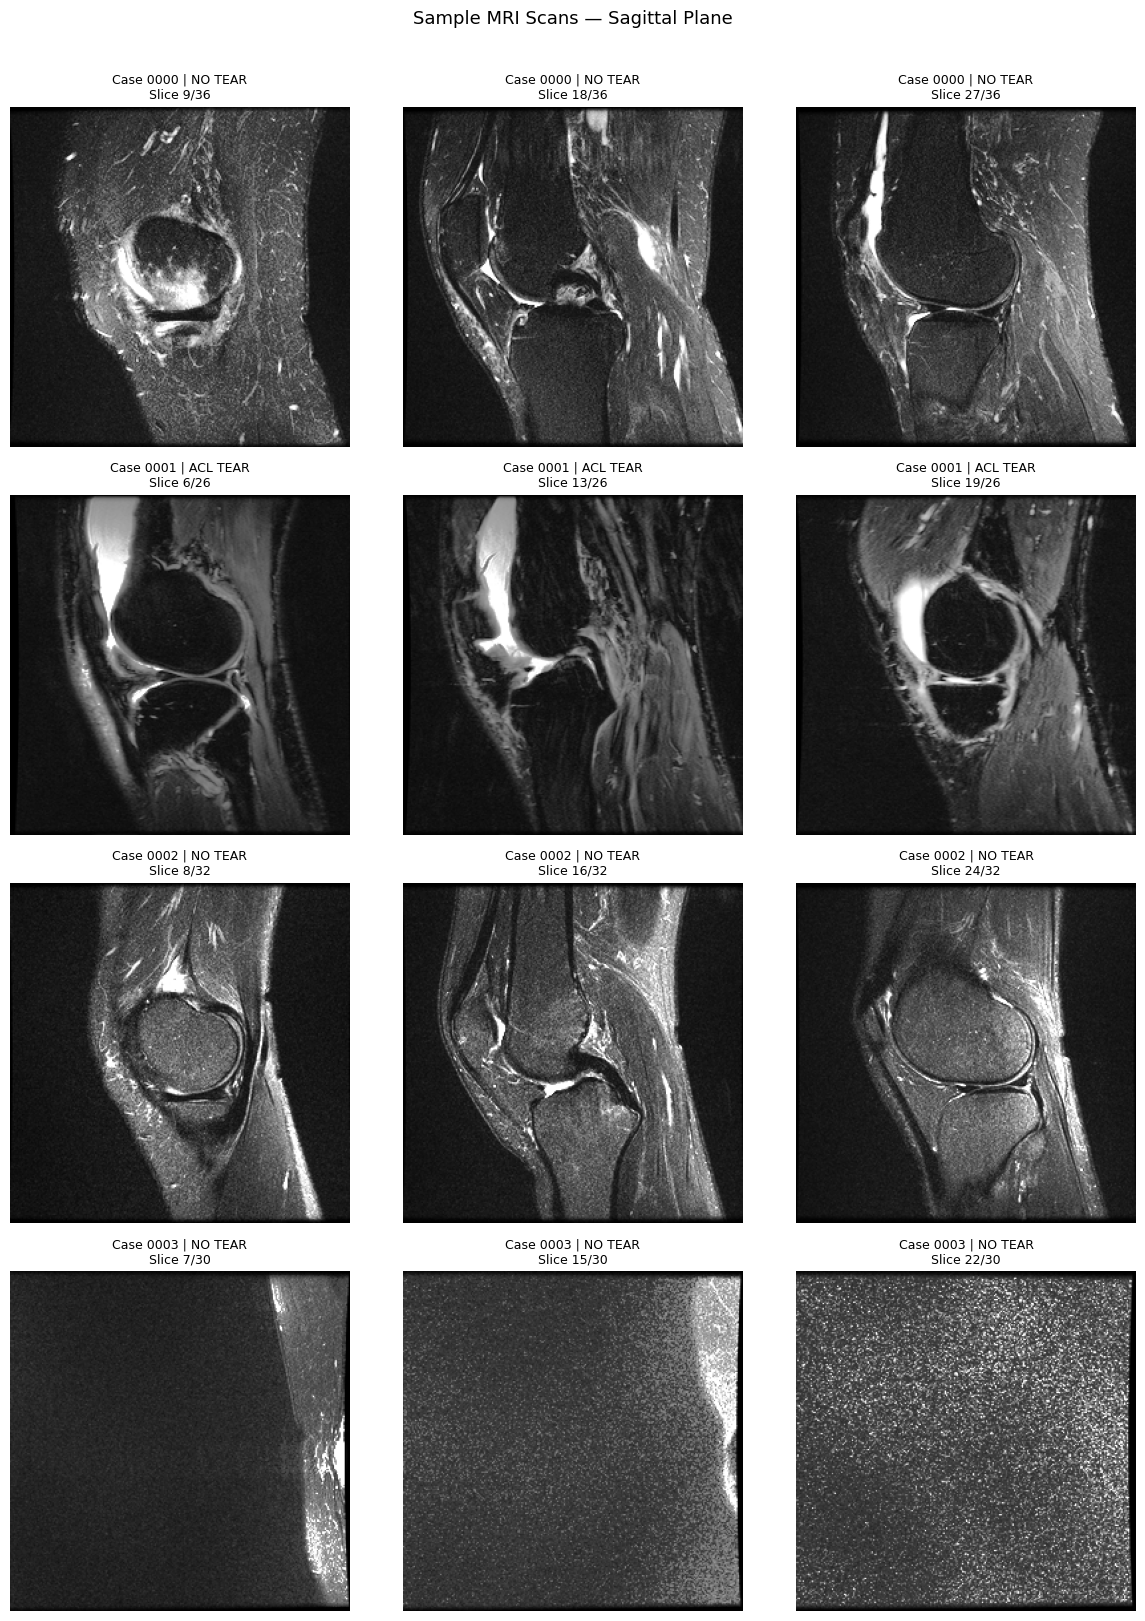

In [5]:
# ─────────────────────────────────────────────────────────────
# CELL 4 — Visualize Sample MRI Scans
# ─────────────────────────────────────────────────────────────
# Always visualize your data before training.
# Confirms the scans loaded correctly and look as expected.

def show_sample_scans(data_dir, csv_path, num_samples=4):
    df      = pd.read_csv(csv_path, header=None, names=['case', 'label'])
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, num_samples * 4))

    for i in range(num_samples):
        row       = df.iloc[i]
        case_id   = int(row['case'])
        label     = int(row['label'])
        label_str = 'ACL TEAR' if label == 1 else 'NO TEAR'

        vol   = np.load(os.path.join(data_dir, f'{case_id:04d}.npy'))
        total = vol.shape[0]

        # Show early, middle, and late slices
        for j, slice_idx in enumerate([total // 4, total // 2, (3 * total) // 4]):
            axes[i, j].imshow(vol[slice_idx], cmap='gray')
            axes[i, j].set_title(
                f'Case {case_id:04d} | {label_str}\nSlice {slice_idx}/{total}',
                fontsize=9
            )
            axes[i, j].axis('off')

    plt.suptitle('Sample MRI Scans — Sagittal Plane', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


show_sample_scans(TRAIN_DIR, TRAIN_CSV, num_samples=4)

In [6]:
# ─────────────────────────────────────────────────────────────
# CELL 5 — Model Architecture
# ─────────────────────────────────────────────────────────────
#
# WHY ResNet18 + Transfer Learning?
# ResNet18 was pretrained on 1.2M ImageNet images.
# It already knows edges, textures, and shapes.
# We reuse that knowledge and fine-tune it on MRI data.
# This is critical when your dataset is small (~1000 scans).
#
# ARCHITECTURE FLOW:
# [S slices] → ResNet18 per slice → [S x 512 features]
#           → Max pool across S → [512 features]
#           → FC head → [1 logit] → sigmoid → probability

class MRNetModel(nn.Module):
    def __init__(self, dropout_rate=0.3):
        super(MRNetModel, self).__init__()

        # Pretrained ResNet18
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        # Remove the final classification layer
        # We keep only the feature extraction backbone
        self.feature_extractor = nn.Sequential(*list(resnet.children())[:-1])
        # Output per slice: [batch, 512, 1, 1]

        # Classification head
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(64, 1)        # single logit output
        )

    def forward(self, x):
        """
        x : [batch, num_slices, 3, 224, 224]
        """
        batch_size, num_slices, C, H, W = x.shape

        # Merge batch + slice dims for efficient parallel processing
        x = x.view(batch_size * num_slices, C, H, W)

        # Extract 512-dim features from each slice
        features = self.feature_extractor(x)
        # [batch * num_slices, 512, 1, 1]

        # Restore batch dimension
        features = features.view(batch_size, num_slices, 512)
        # [batch, num_slices, 512]

        # Max pool across slices
        # Keeps strongest feature activation seen in any slice.
        # Clinically correct — ACL tear only needs to appear in a few slices.
        features, _ = torch.max(features, dim=1)
        # [batch, 512]

        return self.classifier(features)


# Initialize and move to GPU
model        = MRNetModel(dropout_rate=0.3).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'✓ Model on         : {DEVICE}')
print(f'✓ Parameters       : {total_params:,}')

# Forward pass test with dummy input
with torch.no_grad():
    dummy  = torch.randn(1, 10, 3, 224, 224).to(DEVICE)
    output = model(dummy)
    print(f'✓ Forward pass OK  : input {list(dummy.shape)} → output {list(output.shape)}')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 172MB/s]


✓ Model on         : cuda
✓ Parameters       : 11,324,353
✓ Forward pass OK  : input [1, 10, 3, 224, 224] → output [1, 1]


In [8]:
# ─────────────────────────────────────────────────────────────
# CELL 6 — Training Loop
# ─────────────────────────────────────────────────────────────

# Loss — BCEWithLogitsLoss handles sigmoid internally (more stable)
# pos_weight corrects for class imbalance
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Adam optimizer — adapts learning rate per parameter automatically
optimizer = optim.Adam(
    model.parameters(),
    lr           = CONFIG['learning_rate'],
    weight_decay = CONFIG['weight_decay'],
)

# Halve LR if validation AUC doesn't improve for 3 epochs
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3
)

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss  = 0.0
    num_batches = len(loader)

    for batch_idx, (volumes, labels) in enumerate(loader):
        volumes = volumes.to(device)
        labels  = labels.to(device).unsqueeze(1)   # [B] → [B, 1]

        optimizer.zero_grad()
        logits = model(volumes)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if (batch_idx + 1) % 20 == 0 or (batch_idx + 1) == num_batches:
            print(f'  Batch [{batch_idx + 1}/{num_batches}]  Loss: {loss.item():.4f}')

    return total_loss / num_batches


def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_labels = []
    all_probs  = []

    with torch.no_grad():
        for volumes, labels in loader:
            volumes = volumes.to(device)
            labels  = labels.to(device).unsqueeze(1)

            logits     = model(volumes)
            loss       = criterion(logits, labels)
            total_loss += loss.item()

            probs = torch.sigmoid(logits)
            all_probs.extend(probs.cpu().numpy().flatten().tolist())
            all_labels.extend(labels.cpu().numpy().flatten().tolist())

    avg_loss = total_loss / len(loader)
    auc      = roc_auc_score(all_labels, all_probs)

    return avg_loss, auc, all_labels, all_probs


def run_training(model, train_loader, valid_loader,
                 optimizer, criterion, scheduler, config):

    best_auc       = 0.0
    patience_count = 0
    history        = {'train_loss': [], 'valid_loss': [], 'valid_auc': []}

    print('=' * 60)
    print('TRAINING STARTED')
    print('=' * 60)

    for epoch in range(1, config['num_epochs'] + 1):
        print(f'\nEpoch [{epoch}/{config["num_epochs"]}]')
        print('-' * 40)

        train_loss                      = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
        valid_loss, valid_auc, _, _     = validate(model, valid_loader, criterion, DEVICE)

        scheduler.step(valid_auc)

        history['train_loss'].append(train_loss)
        history['valid_loss'].append(valid_loss)
        history['valid_auc'].append(valid_auc)

        print(f'\n  Train Loss : {train_loss:.4f}')
        print(f'  Valid Loss : {valid_loss:.4f}')
        print(f'  Valid AUC  : {valid_auc:.4f}')

        if valid_auc > best_auc:
            best_auc       = valid_auc
            patience_count = 0
            ckpt_path      = os.path.join(CHECKPOINT_DIR, 'best_model.pt')
            torch.save({
                'epoch'      : epoch,
                'model_state': model.state_dict(),
                'optim_state': optimizer.state_dict(),
                'best_auc'   : best_auc,
                'config'     : config,
            }, ckpt_path)
            print(f'  ✓ Best model saved — AUC: {best_auc:.4f}')
        else:
            patience_count += 1
            print(f'  No improvement. Patience: {patience_count}/{config["patience"]}')

        if patience_count >= config['patience']:
            print(f'\n⚠ Early stopping triggered at epoch {epoch}')
            break

    print(f'\n{"=" * 60}')
    print(f'TRAINING COMPLETE — Best AUC: {best_auc:.4f}')
    print(f'{"=" * 60}')
    return history


history = run_training(
    model, train_loader, valid_loader,
    optimizer, criterion, scheduler, CONFIG
)

TRAINING STARTED

Epoch [1/30]
----------------------------------------
  Batch [20/142]  Loss: 1.8270
  Batch [40/142]  Loss: 0.7953
  Batch [60/142]  Loss: 0.6557
  Batch [80/142]  Loss: 1.0920
  Batch [100/142]  Loss: 0.6859
  Batch [120/142]  Loss: 0.9587
  Batch [140/142]  Loss: 0.9120
  Batch [142/142]  Loss: 1.8119

  Train Loss : 1.1070
  Valid Loss : 1.4313
  Valid AUC  : 0.7938
  ✓ Best model saved — AUC: 0.7938

Epoch [2/30]
----------------------------------------
  Batch [20/142]  Loss: 1.2179
  Batch [40/142]  Loss: 0.8549
  Batch [60/142]  Loss: 1.0142
  Batch [80/142]  Loss: 0.6317
  Batch [100/142]  Loss: 0.4574
  Batch [120/142]  Loss: 0.7822
  Batch [140/142]  Loss: 0.8569
  Batch [142/142]  Loss: 1.3096

  Train Loss : 1.0239
  Valid Loss : 1.1446
  Valid AUC  : 0.8900
  ✓ Best model saved — AUC: 0.8900

Epoch [3/30]
----------------------------------------
  Batch [20/142]  Loss: 0.4283
  Batch [40/142]  Loss: 0.6180
  Batch [60/142]  Loss: 0.8933
  Batch [80/142] 

✓ Loaded best model from epoch 25 (AUC: 0.9719)

Classification Report:
              precision    recall  f1-score   support

 No ACL Tear       0.84      0.94      0.89        66
    ACL Tear       0.91      0.78      0.84        54

    accuracy                           0.87       120
   macro avg       0.88      0.86      0.86       120
weighted avg       0.87      0.87      0.87       120

AUC-ROC     : 0.9719
Sensitivity : 0.7778  ← real tears caught
Specificity : 0.9394  ← healthy knees correctly cleared


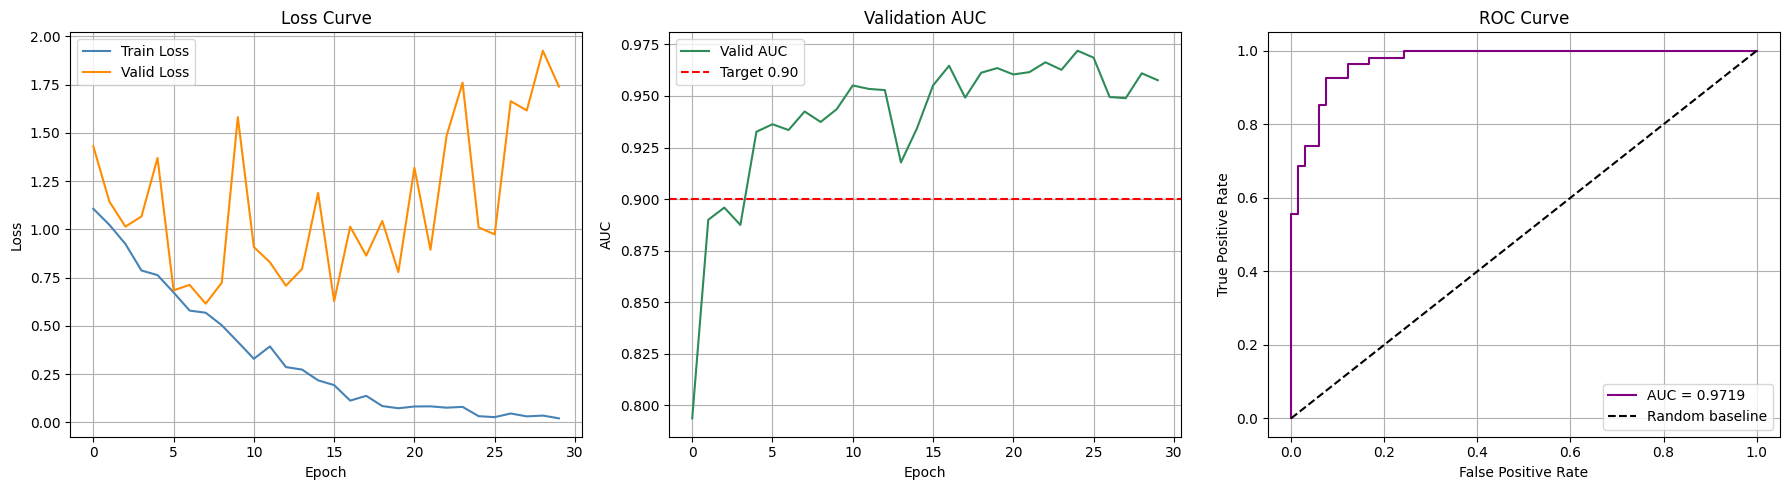

✓ Training curves saved to /content/training_results.png


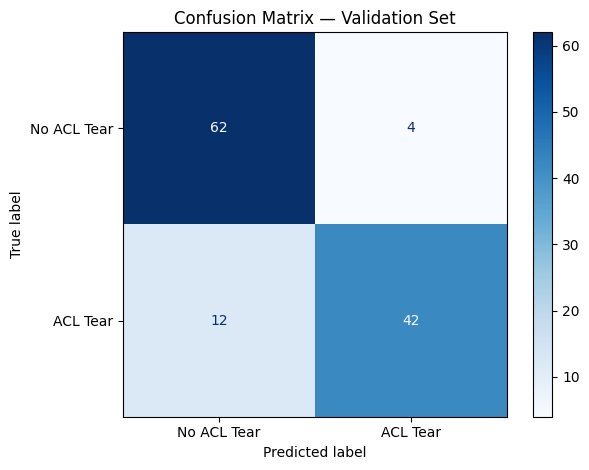

✓ Confusion matrix saved to /content/confusion_matrix.png


In [12]:
# ─────────────────────────────────────────────────────────────
# CELL 7 — Evaluation & Visualizations
# ─────────────────────────────────────────────────────────────

# Load best saved model

ckpt = torch.load(os.path.join(CHECKPOINT_DIR, 'best_model.pt'), map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state'])
print(f'✓ Loaded best model from epoch {ckpt["epoch"]} (AUC: {ckpt["best_auc"]:.4f})')

# Final validation pass
_, final_auc, all_labels, all_probs = validate(model, valid_loader, criterion, DEVICE)
all_preds = [1 if p >= 0.5 else 0 for p in all_probs]

# Classification report
print('\nClassification Report:')
print(classification_report(
    all_labels, all_preds,
    target_names=['No ACL Tear', 'ACL Tear']
))

# Clinical metrics
cm               = confusion_matrix(all_labels, all_preds)
tn, fp, fn, tp   = cm.ravel()
sensitivity      = tp / (tp + fn + 1e-8)
specificity      = tn / (tn + fp + 1e-8)

print(f'AUC-ROC     : {final_auc:.4f}')
print(f'Sensitivity : {sensitivity:.4f}  ← real tears caught')
print(f'Specificity : {specificity:.4f}  ← healthy knees correctly cleared')

# ── Training curves ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['train_loss'], label='Train Loss', color='steelblue')
axes[0].plot(history['valid_loss'], label='Valid Loss', color='darkorange')
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['valid_auc'], label='Valid AUC', color='seagreen')
axes[1].axhline(y=0.9, color='red', linestyle='--', label='Target 0.90')
axes[1].set_title('Validation AUC')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].legend()
axes[1].grid(True)

fpr, tpr, _ = roc_curve(all_labels, all_probs)
axes[2].plot(fpr, tpr, color='purple', label=f'AUC = {final_auc:.4f}')
axes[2].plot([0, 1], [0, 1], 'k--', label='Random baseline')
axes[2].set_title('ROC Curve')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.savefig('/content/training_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Training curves saved to /content/training_results.png')

# ── Confusion matrix ──────────────────────────────────────────
disp = ConfusionMatrixDisplay(cm, display_labels=['No ACL Tear', 'ACL Tear'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Validation Set')
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Confusion matrix saved to /content/confusion_matrix.png')

In [13]:
# ─────────────────────────────────────────────────────────────
# CELL 8 — Save Best Model to Google Drive
# ─────────────────────────────────────────────────────────────
# Colab session storage resets when the session ends.
# Save the trained model weights back to Drive so you
# never have to retrain from scratch.

import shutil

drive_save_path = '/content/drive/MyDrive/MRNet_best_model.pt'
shutil.copy(
    os.path.join(CHECKPOINT_DIR, 'best_model.pt'),
    drive_save_path
)
print(f'✓ Model saved to Google Drive: {drive_save_path}')

# Save training results images too
shutil.copy('/content/training_results.png', '/content/drive/MyDrive/MRNet_training_results.png')
shutil.copy('/content/confusion_matrix.png', '/content/drive/MyDrive/MRNet_confusion_matrix.png')
print('✓ Result plots saved to Google Drive')

✓ Model saved to Google Drive: /content/drive/MyDrive/MRNet_best_model.pt
✓ Result plots saved to Google Drive


In [14]:
# ─────────────────────────────────────────────────────────────
# CELL 9 — Inference on a Single Scan
# ─────────────────────────────────────────────────────────────

def predict_scan(model, npy_path, device, threshold=0.5):
    """
    Predict ACL tear probability for one MRI scan.

    Args:
        model     : trained MRNetModel
        npy_path  : path to a sagittal .npy file
        device    : torch device
        threshold : probability cutoff for positive prediction

    Returns:
        dict with prediction details
    """
    model.eval()

    volume = np.load(npy_path)
    v_min, v_max = volume.min(), volume.max()
    volume = (volume - v_min) / (v_max - v_min + 1e-8)

    slices = []
    for s in range(volume.shape[0]):
        t = torch.tensor(volume[s], dtype=torch.float32).unsqueeze(0)
        t = TF.resize(t, [224, 224], antialias=True)
        t = t.repeat(3, 1, 1)
        slices.append(t)

    volume_tensor = torch.stack(slices).unsqueeze(0).to(device)

    with torch.no_grad():
        logit       = model(volume_tensor)
        probability = torch.sigmoid(logit).item()

    decision   = 'ACL TEAR DETECTED' if probability >= threshold else 'NO TEAR DETECTED'
    confidence = probability if probability >= threshold else 1 - probability

    return {
        'file'       : os.path.basename(npy_path),
        'probability': round(probability, 4),
        'decision'   : decision,
        'confidence' : f'{confidence * 100:.1f}%',
    }


# Test on first 5 validation scans
print('=' * 50)
print('INFERENCE — SAMPLE VALIDATION SCANS')
print('=' * 50)

df_valid    = pd.read_csv(VALID_CSV, header=None, names=['case', 'label'])
valid_files = sorted(os.listdir(VALID_DIR))

for i in range(5):
    scan_path    = os.path.join(VALID_DIR, valid_files[i])
    true_label   = df_valid.iloc[i]['label']
    true_str     = 'ACL TEAR' if true_label == 1 else 'NO TEAR'
    result       = predict_scan(model, scan_path, DEVICE)

    match = '✓' if (result['probability'] >= 0.5) == bool(true_label) else '✗'

    print(f"\n  {match} File        : {result['file']}")
    print(f"    True Label  : {true_str}")
    print(f"    Prediction  : {result['decision']}")
    print(f"    Probability : {result['probability']}")
    print(f"    Confidence  : {result['confidence']}")

print('\n' + '=' * 50)
print('NOTE: This is a clinical decision support tool.')
print('Final diagnosis must be confirmed by a radiologist.')
print('=' * 50)

INFERENCE — SAMPLE VALIDATION SCANS

  ✓ File        : 1130.npy
    True Label  : NO TEAR
    Prediction  : NO TEAR DETECTED
    Probability : 0.0
    Confidence  : 100.0%

  ✓ File        : 1131.npy
    True Label  : NO TEAR
    Prediction  : NO TEAR DETECTED
    Probability : 0.0035
    Confidence  : 99.6%

  ✓ File        : 1132.npy
    True Label  : NO TEAR
    Prediction  : NO TEAR DETECTED
    Probability : 0.0011
    Confidence  : 99.9%

  ✓ File        : 1133.npy
    True Label  : NO TEAR
    Prediction  : NO TEAR DETECTED
    Probability : 0.0001
    Confidence  : 100.0%

  ✓ File        : 1134.npy
    True Label  : NO TEAR
    Prediction  : NO TEAR DETECTED
    Probability : 0.0
    Confidence  : 100.0%

NOTE: This is a clinical decision support tool.
Final diagnosis must be confirmed by a radiologist.
